# Uplift Modeling: T-Learner, S-Learner, and X-Learner

End-to-end demo of `UpliftRecommender` with all three uplift modes on a synthetic
marketing campaign dataset.

**Scenario**: An e-commerce company runs a marketing campaign with two treatments
(email coupon, push notification) and a control group (no action). The goal is to
identify which treatment maximises *incremental* conversion — not just who converts,
but who converts *because of* the treatment.

**Three meta-learner strategies**:

| Mode | How it works |
|---|---|
| **T-Learner** | Trains one model per treatment group; uplift = treatment score − control score |
| **S-Learner** | Trains one model with treatment indicator as a feature; uplift by counterfactual swap |
| **X-Learner** | T-Learner + cross-fitted imputed effects + propensity weighting (Künzel et al., 2019) |

All three use the same `UpliftRecommender` API — only the `mode` and `scorer` type differ.

## 1. Imports

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from skrec.dataset.interactions_dataset import InteractionsDataset
from skrec.dataset.users_dataset import UsersDataset
from skrec.estimator.classification.xgb_classifier import XGBClassifierEstimator
from skrec.recommender.uplift_model.uplift_recommender import UpliftRecommender
from skrec.scorer.independent import IndependentScorer
from skrec.scorer.universal import UniversalScorer

logging.basicConfig(level=logging.WARNING)
logging.getLogger("recommender").setLevel(logging.WARNING)

rng = np.random.default_rng(42)

DATA_DIR = Path("data/uplift-synthetic")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Imports OK")

Imports OK


## 2. Generate Synthetic Uplift Dataset

We create a dataset with **known ground-truth treatment effects** so we can verify
that the uplift models recover them.

**Data generation process**:
- 2,000 users with 3 features: `age` (18–65), `income` (20k–120k), `engagement_score` (0–1)
- 3 groups: `email_coupon`, `push_notification`, and `control`
- Base conversion rate depends on user features
- **Email coupon** has a strong positive effect on high-income users
- **Push notification** has a moderate positive effect on high-engagement users
- The uplift is *heterogeneous* — it varies by user segment

In [2]:
N_USERS = 2000

# User features
user_ids = [f"user_{i}" for i in range(N_USERS)]
age = rng.integers(18, 65, size=N_USERS).astype(float)
income = rng.uniform(20_000, 120_000, size=N_USERS)
engagement = rng.uniform(0, 1, size=N_USERS)

users_df = pd.DataFrame(
    {
        "USER_ID": user_ids,
        "age": age,
        "income": income,
        "engagement_score": engagement,
    }
)

# Assign each user to all 3 groups (randomised trial)
items = ["email_coupon", "push_notification", "control"]
rows = []

for i in range(N_USERS):
    # Base conversion probability (same across groups)
    base_prob = 0.1 + 0.2 * (income[i] - 20_000) / 100_000 + 0.1 * engagement[i]

    for item in items:
        prob = base_prob
        if item == "email_coupon":
            # Strong uplift for high-income users
            prob += 0.15 * (income[i] - 20_000) / 100_000
        elif item == "push_notification":
            # Moderate uplift for high-engagement users
            prob += 0.10 * engagement[i]

        prob = np.clip(prob, 0.01, 0.99)
        outcome = float(rng.binomial(1, prob))
        rows.append({"USER_ID": user_ids[i], "ITEM_ID": item, "OUTCOME": outcome})

interactions_df = pd.DataFrame(rows)

print(f"Users: {N_USERS:,}")
print(f"Interactions: {len(interactions_df):,} ({N_USERS} users × {len(items)} groups)")
print("\nConversion rates by group:")
print(interactions_df.groupby("ITEM_ID")["OUTCOME"].mean().to_string())

Users: 2,000
Interactions: 6,000 (2000 users × 3 groups)

Conversion rates by group:
ITEM_ID
control              0.2415
email_coupon         0.3270
push_notification    0.3000


## 3. Save to Disk and Create Datasets

The library expects `InteractionsDataset` and `UsersDataset` objects backed by CSV files.
Data is saved to `data/uplift-synthetic/` and regenerated only if the files don't already exist.

In [3]:
interactions_path = str(DATA_DIR / "interactions.csv")
users_path = str(DATA_DIR / "users.csv")

if not Path(interactions_path).exists():
    interactions_df.to_csv(interactions_path, index=False)
    users_df.to_csv(users_path, index=False)
    print(f"Generated and saved to {DATA_DIR}")
else:
    print(f"Data already exists at {DATA_DIR}, reusing.")

interactions_ds = InteractionsDataset(data_location=interactions_path)
users_ds = UsersDataset(data_location=users_path)

print(f"Interactions schema: {[c for c in interactions_df.columns]}")
print(f"Users schema: {[c for c in users_df.columns]}")

Data already exists at data/uplift-synthetic, reusing.
Interactions schema: ['USER_ID', 'ITEM_ID', 'OUTCOME']
Users schema: ['USER_ID', 'age', 'income', 'engagement_score']


## 4. Train All Three Uplift Models

Each mode uses the same training data and control item. The only differences are:

| Mode | Scorer | `mode` param |
|---|---|---|
| T-Learner | `IndependentScorer` | `None` (auto-detected) |
| S-Learner | `UniversalScorer` | `None` (auto-detected) |
| X-Learner | `IndependentScorer` | `"x_learner"` |

In [4]:
xgb_params = {"max_depth": 4, "n_estimators": 100, "learning_rate": 0.1, "verbosity": 0, "random_state": 42}

models = {}

# T-Learner: IndependentScorer → auto-detected as T-Learner
print("Training T-Learner...")
scorer_t = IndependentScorer(estimator=XGBClassifierEstimator(xgb_params))
models["T-Learner"] = UpliftRecommender(scorer=scorer_t, control_item_id="control")
models["T-Learner"].train(interactions_ds=interactions_ds, users_ds=users_ds, items_ds=None)
print("  Done.")

# S-Learner: UniversalScorer → auto-detected as S-Learner
print("Training S-Learner...")
scorer_s = UniversalScorer(estimator=XGBClassifierEstimator(xgb_params))
models["S-Learner"] = UpliftRecommender(scorer=scorer_s, control_item_id="control")
models["S-Learner"].train(interactions_ds=interactions_ds, users_ds=users_ds, items_ds=None)
print("  Done.")

# X-Learner: IndependentScorer + explicit mode="x_learner"
print("Training X-Learner...")
scorer_x = IndependentScorer(estimator=XGBClassifierEstimator(xgb_params))
models["X-Learner"] = UpliftRecommender(scorer=scorer_x, control_item_id="control", mode="x_learner")
models["X-Learner"].train(interactions_ds=interactions_ds, users_ds=users_ds, items_ds=None)
print("  Done.")

print("\nAll 3 models trained.")

2026-04-16 22:49:24,003 - skrec.scorer.independent - INFO Checking if the target label has only two unique values for classification


INFO:skrec.scorer.independent:Checking if the target label has only two unique values for classification


2026-04-16 22:49:24,004 - skrec.scorer.independent - INFO Check Successful!


INFO:skrec.scorer.independent:Check Successful!


2026-04-16 22:49:24,007 - skrec.scorer.independent - INFO Checking if the target label has only two unique values for classification


...

2026-04-16 22:49:24,605 - skrec.scorer.independent - INFO Check Successful!


INFO:skrec.scorer.independent:Check Successful!


  Done.
Training S-Learner...
  Done.
Training X-Learner...


  Done.

All 3 models trained.


/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.819616647588347e-11.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.819616647588347e-11.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.819616647588347e-11.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-c

## 5. Score All Users

`score_items()` returns a DataFrame with one column per treatment item.
Each value is the estimated **uplift** (incremental conversion probability vs. control).

In [5]:
all_scores = {}
for name, model in models.items():
    scores = model.score_items(users=users_df)
    all_scores[name] = scores
    print(f"\n{name} uplift scores (first 5 users):")
    print(scores.head().to_string(float_format="{:.4f}".format))
    print(
        f"\n  Mean uplift:  email_coupon={scores['email_coupon'].mean():.4f}  "
        f"push_notification={scores['push_notification'].mean():.4f}"
    )

2026-04-16 22:49:25,117 - skrec.scorer.base_scorer - INFO Receiving DataFrames for Interactions and Users


INFO:skrec.scorer.base_scorer:Receiving DataFrames for Interactions and Users


2026-04-16 22:49:25,119 - skrec.scorer.base_scorer - INFO Shape of Interactions DataFrame: (2000, 1)


INFO:skrec.scorer.base_scorer:Shape of Interactions DataFrame: (2000, 1)


2026-04-16 22:49:25,120 - skrec.scorer.base_scorer - INFO Shape of Users DataFrame: (2000, 4)


...

2026-04-16 22:49:25,193 - skrec.scorer.base_scorer - INFO Merging DataFrames


INFO:skrec.scorer.base_scorer:Merging DataFrames


2026-04-16 22:49:25,197 - skrec.scorer.base_scorer - INFO Completed Merging User-Interactions DataFrames


INFO:skrec.scorer.base_scorer:Completed Merging User-Interactions DataFrames



T-Learner uplift scores (first 5 users):
   email_coupon  push_notification
0       -0.2063            -0.1731
1        0.0644            -0.0386
2        0.1014             0.0720
3       -0.1946            -0.0655
4        0.1425            -0.0260

  Mean uplift:  email_coupon=0.0854  push_notification=0.0588

S-Learner uplift scores (first 5 users):
   email_coupon  push_notification
0       -0.0483            -0.0240
1        0.0650             0.0339
2        0.0303             0.0171
3       -0.0161            -0.0254
4        0.0779             0.0243

  Mean uplift:  email_coupon=0.0803  push_notification=0.0563

X-Learner uplift scores (first 5 users):
   email_coupon  push_notification
0       -0.0254             0.0479
1        0.0988             0.0716
2        0.0006             0.0159
3        0.0139             0.0554
4        0.0931             0.0311

  Mean uplift:  email_coupon=0.0855  push_notification=0.0586


## 6. Recommendations: Which Treatment to Assign?

`recommend()` returns the treatment with the highest uplift per user.
If all treatments have negative uplift, it recommends `control` (do nothing).

In [6]:
for name, model in models.items():
    recs = model.recommend(users=users_df, top_k=1)
    rec_series = pd.Series(recs[:, 0])
    print(f"\n{name} — recommended treatment distribution:")
    print(rec_series.value_counts().to_string())

2026-04-16 22:49:25,207 - skrec.scorer.base_scorer - INFO Receiving DataFrames for Interactions and Users


INFO:skrec.scorer.base_scorer:Receiving DataFrames for Interactions and Users


2026-04-16 22:49:25,209 - skrec.scorer.base_scorer - INFO Shape of Interactions DataFrame: (2000, 1)


INFO:skrec.scorer.base_scorer:Shape of Interactions DataFrame: (2000, 1)


2026-04-16 22:49:25,210 - skrec.scorer.base_scorer - INFO Shape of Users DataFrame: (2000, 4)


...

2026-04-16 22:49:25,262 - skrec.scorer.base_scorer - INFO Completed Merging User-Interactions DataFrames


INFO:skrec.scorer.base_scorer:Completed Merging User-Interactions DataFrames


2026-04-16 22:49:25,265 - skrec.recommender.uplift_model.uplift_recommender - INFO For 59 user(s), the number of recommendations with positive uplift was less than top_k=1.


INFO:skrec.recommender.uplift_model.uplift_recommender:For 59 user(s), the number of recommendations with positive uplift was less than top_k=1.



T-Learner — recommended treatment distribution:
email_coupon         934
push_notification    720
control              346

S-Learner — recommended treatment distribution:
email_coupon         1209
push_notification     648
control               143

X-Learner — recommended treatment distribution:
email_coupon         1351
push_notification     590
control                59


## 7. Validate Against Ground Truth

Since we generated the data with known treatment effects, we can check whether
the models correctly identify **which users benefit most from each treatment**.

**Ground truth**:
- Email coupon uplift is proportional to `income`
- Push notification uplift is proportional to `engagement_score`

We compute the **rank correlation** between each model's predicted uplift and
the true uplift driver for each treatment.

In [7]:
from scipy.stats import spearmanr

# True uplift drivers (normalised)
true_email_uplift = (users_df["income"] - 20_000) / 100_000
true_push_uplift = users_df["engagement_score"]

print(f"{'Model':<12} {'Email↔Income (ρ)':>18} {'Push↔Engagement (ρ)':>22}")
print("=" * 55)

for name, scores in all_scores.items():
    corr_email = spearmanr(scores["email_coupon"], true_email_uplift).statistic
    corr_push = spearmanr(scores["push_notification"], true_push_uplift).statistic
    print(f"{name:<12} {corr_email:>18.4f} {corr_push:>22.4f}")

print("\nHigher ρ = model better captures which users benefit most from each treatment.")

Model          Email↔Income (ρ)    Push↔Engagement (ρ)
T-Learner                0.3587                 0.1774
S-Learner                0.7033                 0.3366
X-Learner                0.9464                 0.7685

Higher ρ = model better captures which users benefit most from each treatment.


## 8. Uplift Distribution by User Segment

Visualise how predicted uplift varies across user segments to confirm
the models capture heterogeneous treatment effects.

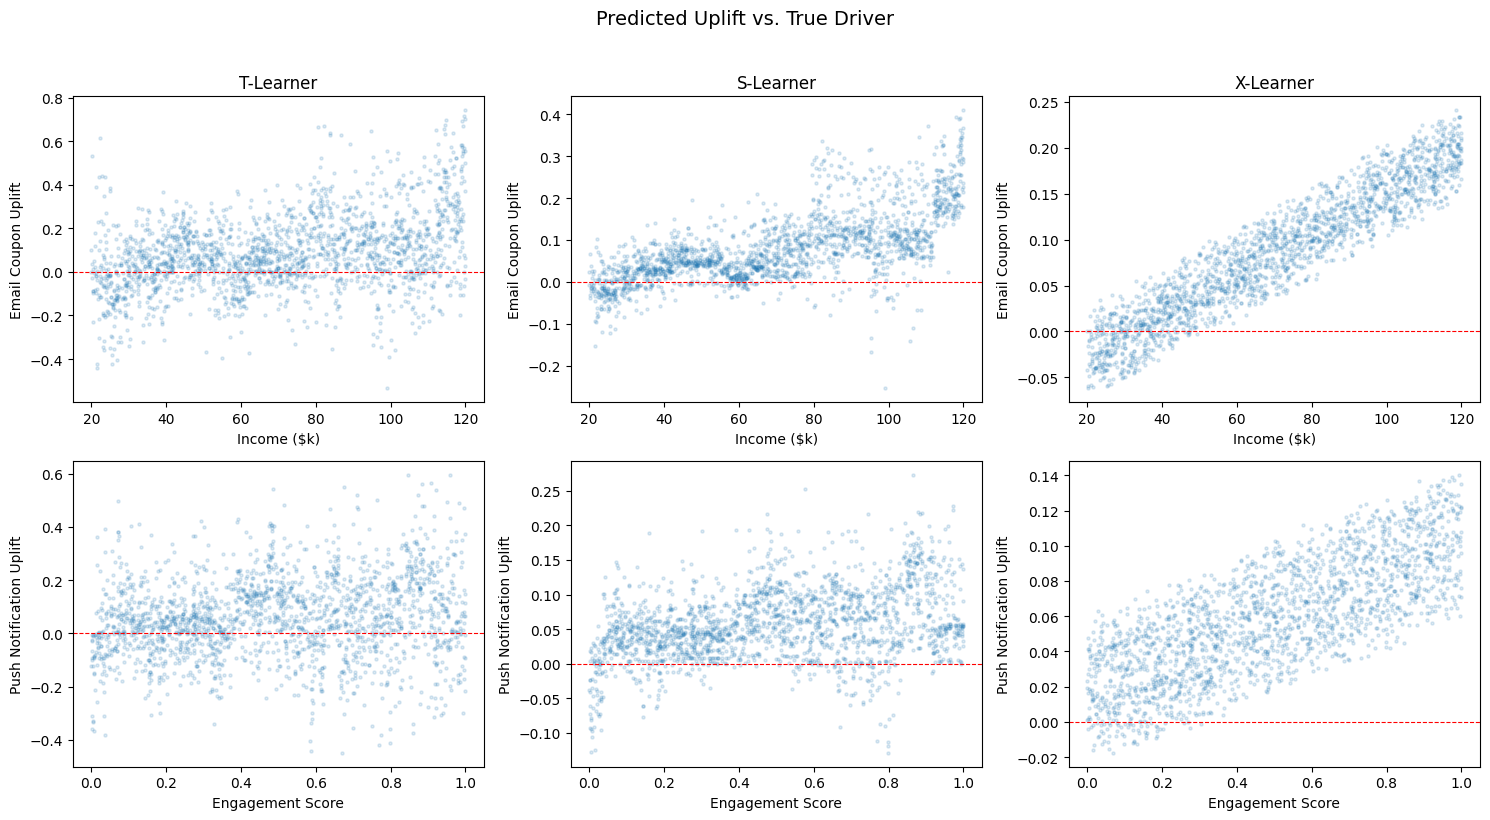

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, scores) in enumerate(all_scores.items()):
    # Top row: email_coupon uplift vs income
    ax = axes[0, col]
    ax.scatter(users_df["income"] / 1000, scores["email_coupon"], alpha=0.15, s=5)
    ax.set_xlabel("Income ($k)")
    ax.set_ylabel("Email Coupon Uplift")
    ax.set_title(f"{name}")
    ax.axhline(0, color="red", ls="--", lw=0.8)

    # Bottom row: push_notification uplift vs engagement
    ax = axes[1, col]
    ax.scatter(users_df["engagement_score"], scores["push_notification"], alpha=0.15, s=5)
    ax.set_xlabel("Engagement Score")
    ax.set_ylabel("Push Notification Uplift")
    ax.axhline(0, color="red", ls="--", lw=0.8)

fig.suptitle("Predicted Uplift vs. True Driver", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Item Subset Filtering

`set_item_subset()` restricts scoring/recommendations to a subset of treatments.
This is useful when certain treatments are temporarily unavailable.

In [9]:
model = models["T-Learner"]

# Only score email_coupon
model.set_item_subset(["email_coupon"])
filtered_scores = model.score_items(users=users_df)
print(f"Filtered columns: {list(filtered_scores.columns)}")
print(filtered_scores.head(3).to_string(float_format="{:.4f}".format))

# Recommendations now choose between email_coupon and control only
recs = model.recommend(users=users_df, top_k=1)
print(f"\nRecommended (email_coupon vs control only): {pd.Series(recs[:, 0]).value_counts().to_dict()}")

# Clear the subset to restore full scoring
model.clear_item_subset()
full_scores = model.score_items(users=users_df)
print(f"\nRestored columns: {list(full_scores.columns)}")

2026-04-16 22:49:25,787 - skrec.scorer.base_scorer - INFO Receiving DataFrames for Interactions and Users


INFO:skrec.scorer.base_scorer:Receiving DataFrames for Interactions and Users


2026-04-16 22:49:25,788 - skrec.scorer.base_scorer - INFO Shape of Interactions DataFrame: (2000, 1)


INFO:skrec.scorer.base_scorer:Shape of Interactions DataFrame: (2000, 1)


2026-04-16 22:49:25,788 - skrec.scorer.base_scorer - INFO Shape of Users DataFrame: (2000, 4)


...

2026-04-16 22:49:25,813 - skrec.scorer.base_scorer - INFO Merging DataFrames


INFO:skrec.scorer.base_scorer:Merging DataFrames


2026-04-16 22:49:25,814 - skrec.scorer.base_scorer - INFO Completed Merging User-Interactions DataFrames


INFO:skrec.scorer.base_scorer:Completed Merging User-Interactions DataFrames


Filtered columns: ['email_coupon']
   email_coupon
0       -0.2063
1        0.0644
2        0.1014

Recommended (email_coupon vs control only): {'email_coupon': 1408, 'control': 592}

Restored columns: ['email_coupon', 'push_notification']


## 10. Summary

| Feature | API |
|---|---|
| T-Learner | `UpliftRecommender(IndependentScorer(est), control_item_id="control")` |
| S-Learner | `UpliftRecommender(UniversalScorer(est), control_item_id="control")` |
| X-Learner | `UpliftRecommender(IndependentScorer(est), control_item_id="control", mode="x_learner")` |
| Score all users | `recommender.score_items(users=users_df)` → DataFrame of uplift scores |
| Recommend treatment | `recommender.recommend(users=users_df, top_k=1)` → best treatment per user |
| Filter treatments | `recommender.set_item_subset(["email_coupon"])` |

**When to use which**:
- **T-Learner**: Simple, fast, good default. Works well when treatment and control groups are large.
- **S-Learner**: Best when items have features (uses `UniversalScorer` with item feature concatenation). Can suffer from regularisation bias — the model may ignore the treatment indicator.
- **X-Learner**: Best when treatment/control group sizes are imbalanced. Propensity weighting corrects for this. More expensive (5 models per treatment vs 2 for T-Learner).